In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import time

In [3]:
df = pd.read_csv('pid_errors_1.csv')
df.head()


,time_ms,errorX,errorY
0,1000,-11,-5.5
1,1021,-11,-5.5
2,1043,-13,-6.5
3,1064,-14,-6.0
4,1086,-15,-6.5


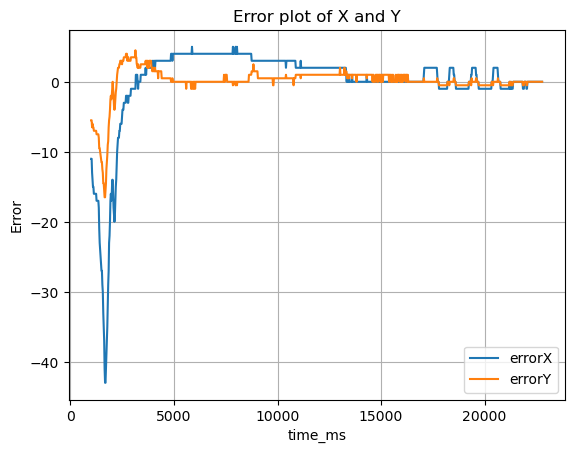

In [46]:
df.plot(x = 'time_ms', y = ['errorX', 'errorY'])
plt.ylabel('Error')
plt.title('Error plot of X and Y')
plt.grid()
plt.savefig('images/error_plot')

Standard Deviation in x: 0.9805659685963145
Standard Deviation in y: 0.4359286897666175


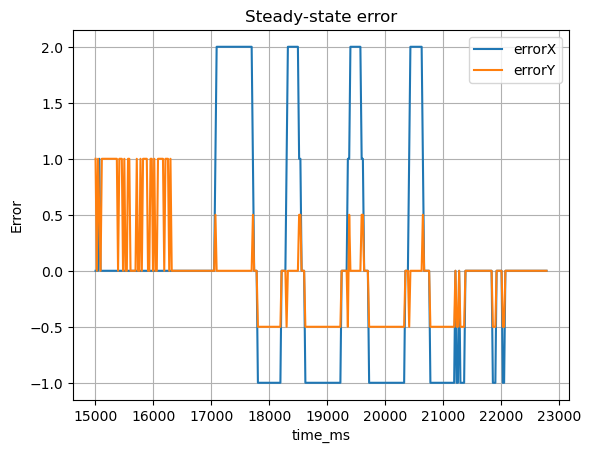

In [50]:
# steady state around 15000
ss = df[df['time_ms'] >= 15000]
ss.plot(x = 'time_ms', y = ['errorX', 'errorY'])
print ('Standard Deviation in x:' ,ss['errorX'].std())
print ('Standard Deviation in y:' ,ss['errorY'].std())
plt.title('Steady-state error')
plt.ylabel('Error')
plt.grid()
plt.savefig('images/ss_error')


In [7]:
ss_error_df = pd.read_csv('pid_log.csv')
ss_error_df.head()

,time_ms,s1,s2,s3,errorX,errorY,posX,posY
0,1000,1,10,0,-10.0,-4.0,89.70,89.88
1,1022,1,10,0,-10.0,-4.0,89.50,89.80
2,1045,2,12,1,-11.0,-4.5,89.26,89.70
3,1072,6,17,4,-13.0,-4.5,88.98,89.61
4,1112,1,14,0,-14.0,-6.0,88.68,89.47


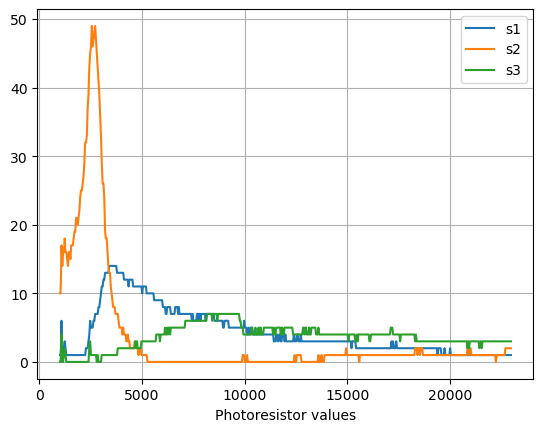

In [11]:
ss_error_df.plot(x = 'time_ms', y = ['s1', 's2', 's3'])
plt.xlabel('Photoresistor values')
plt.grid()

#### ss error

<Axes: xlabel='time_ms'>

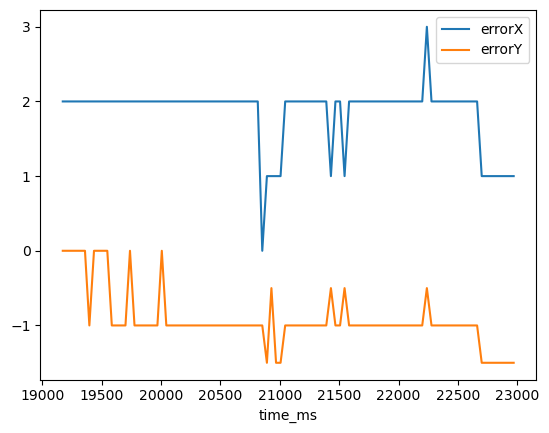

In [20]:
ss_error_df.tail(100).plot(x = 'time_ms', y = ['errorX', 'errorY'])

In [ ]:
ss_X_val = (ss_error_df.tail(100)['errorX'].mode()[0].item())
ss_Y_val = (ss_error_df.tail(100)['errorY'].mode()[0].item())

print(f'The ss error in X is {ss_X_val}, and the ss error in Y is {ss_Y_val}.')

The ss error in X is 2.0, and the ss error in Y is -1.0.


In [ ]:
# settling time
tolerance = ss_X_val*0.02
time_ms = df['time_ms']

for i in range(len(df['errorX'])):
    if abs(df['errorX'][i]) < tolerance:
        if all(abs(e) < tolerance for e in df['errorX'][i:]):
            settling_time_X = time_ms[i]
            break